# VitalsFrame — Exploring the UCI Heart Disease Databases

A end-to-end Pandas walkthrough of four real clinical databases: **load → inspect →
clean → answer questions → export**.

**Data.** 920 patients referred for coronary angiography at four institutions
(Cleveland, Budapest, Zurich/Basel, Long Beach VA), collected 1988. Each patient has 14
attributes — demographics, resting vitals, exercise-test results — plus a diagnosis
graded 0–4.

**The question behind the project.** These four databases share a schema but not a
data-collection culture. Most of the work below is about noticing that, and making sure
the summary statistics do not quietly lie about it.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# Make `src` importable whether the notebook is run from notebooks/ or the repo root.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src import analysis, config as cfg

pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 40)

%matplotlib inline

---
## 1. Load

The archive ships four headerless files, one per institution, with `?` for missing
values. `load_all` reads each with the shared column schema, tags it with a `site`
column, and concatenates them into a single frame.

In [2]:
raw = analysis.load_all()
print(f"{raw.shape[0]:,} patients x {raw.shape[1]} columns")
raw["site"].value_counts()

920 patients x 15 columns


site
cleveland      303
hungary        294
long_beach     200
switzerland    123
Name: count, dtype: int64

---
## 2. Inspect

The three-command first look: `head`, `info`, `describe`.

In [3]:
raw.head()

,site,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,cleveland,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,cleveland,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,cleveland,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,cleveland,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,cleveland,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   site      920 non-null    str    
 1   age       920 non-null    float64
 2   sex       920 non-null    float64
 3   cp        920 non-null    float64
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    float64
 7   restecg   918 non-null    float64
 8   thalach   865 non-null    float64
 9   exang     865 non-null    float64
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    float64
 12  ca        309 non-null    float64
 13  thal      434 non-null    float64
 14  num       920 non-null    int64  
dtypes: float64(13), int64(1), str(1)
memory usage: 107.9 KB


Note the dtypes above: `ca` and `thal` came in as `object`, not numbers. That is the
first signal of a problem — a column that should be numeric is being read as text
because some of its entries are the literal string `?`.

`coerce_dtypes` fixes this: measurements become `float64`, and the code columns become
`Int64` — pandas' *nullable* integer type, which can hold whole numbers **and** missing
values, where plain `int64` cannot.

In [5]:
raw = analysis.coerce_dtypes(raw)
raw.dtypes.to_frame("dtype").T

,site,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
dtype,str,float64,Int64,Int64,float64,float64,Int64,Int64,float64,Int64,float64,Int64,Int64,Int64,Int64


In [6]:
raw.describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
age,920.0,53.51087,9.424685,28.0,47.0,54.0,60.0,77.0
sex,920.0,0.78913,0.408148,0.0,1.0,1.0,1.0,1.0
cp,920.0,3.25,0.930969,1.0,3.0,4.0,4.0,4.0
trestbps,861.0,132.132404,19.06607,0.0,120.0,130.0,140.0,200.0
chol,890.0,199.130337,110.78081,0.0,175.0,223.0,268.0,603.0
fbs,830.0,0.166265,0.372543,0.0,0.0,0.0,0.0,1.0
restecg,918.0,0.604575,0.805827,0.0,0.0,0.0,1.0,2.0
thalach,865.0,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0
exang,865.0,0.389595,0.487941,0.0,0.0,0.0,1.0,1.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.0,0.5,1.5,6.2


`describe` already exposes two impossible readings:

- **`chol` minimum is 0.** Serum cholesterol of 0 mg/dl is not compatible with life.
- **`trestbps` minimum is 0.** Neither is a resting blood pressure of 0.

These are not measurements. They are *"not recorded"* written as a zero — and pandas
has no way to know that, so it happily averages them in.

In [7]:
analysis.data_dictionary()

,description
column,
age,Age in years
sex,"Biological sex (1 = male, 0 = female)"
cp,Chest pain type (1-4)
trestbps,Resting blood pressure (mm Hg)
chol,Serum cholesterol (mg/dl)
fbs,Fasting blood sugar > 120 mg/dl (1 = true)
restecg,Resting ECG result (0-2)
thalach,Maximum heart rate achieved (bpm)
exang,Exercise-induced angina (1 = yes)


---
## 3. Missing values — the heart of this dataset

First the honest `?` gaps.

In [8]:
analysis.missing_report(raw)

,missing,missing_pct,dtype
ca,611,66.4,Int64
thal,486,52.8,Int64
slope,309,33.6,Int64
fbs,90,9.8,Int64
oldpeak,62,6.7,float64
trestbps,59,6.4,float64
thalach,55,6.0,float64
exang,55,6.0,Int64
chol,30,3.3,float64
restecg,2,0.2,Int64


`ca` (67%) and `thal` (53%) are missing for more than half of all patients. But the
*aggregate* number hides the real structure. Break it out by source database:

In [9]:
analysis.missing_by_site(raw)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
site,,,,,,,,,,,,,,
cleveland,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.3,0.7,0.0
hungary,0.0,0.0,0.0,0.3,7.8,2.7,0.3,0.3,0.3,0.0,64.6,99.0,90.5,0.0
long_beach,0.0,0.0,0.0,28.0,3.5,3.5,0.0,26.5,26.5,28.0,51.0,99.0,83.0,0.0
switzerland,0.0,0.0,0.0,1.6,0.0,61.0,0.8,0.8,0.8,4.9,13.8,95.9,42.3,0.0


This is the single most important table in the project.

The gaps are **not missing at random** — they are missing *by institution*. Cleveland
recorded essentially everything; Hungary and Long Beach almost never ran the fluoroscopy
(`ca`) or thallium (`thal`) tests.

The practical consequence: **any pooled analysis of `ca`, `thal` or `slope` is really an
analysis of Cleveland**, dressed up as an analysis of 920 patients. Dropping rows with
missing values here would not shrink the dataset evenly — it would delete three
hospitals.

### Now the dishonest gaps: sentinel zeros

The `?` values are declared. The zeros are not.

In [10]:
zeros = pd.DataFrame({
    "chol == 0": raw.groupby("site")["chol"].apply(lambda s: (s == 0).sum()),
    "trestbps == 0": raw.groupby("site")["trestbps"].apply(lambda s: (s == 0).sum()),
    "n_patients": raw.groupby("site").size(),
})
zeros

,chol == 0,trestbps == 0,n_patients
site,,,
cleveland,0,0,303
hungary,0,0,294
long_beach,49,1,200
switzerland,123,0,123


**Every single one of the 123 Swiss cholesterol readings is a zero**, and Long Beach adds
another 49 — 172 fake values in total, none of them flagged as missing anywhere in the
file.

Left untreated they drag the pooled cholesterol mean down by nearly 50 mg/dl, which is
enough to move the entire dataset across a clinical threshold — from "high" to
"desirable" — and invert the headline finding.

In [11]:
naive = raw["chol"].mean()
honest = raw["chol"].mask(raw["chol"] == 0).mean()
print(f"mean cholesterol treating 0 as a reading : {naive:6.1f} mg/dl")
print(f"mean cholesterol treating 0 as missing   : {honest:6.1f} mg/dl")
print(f"difference                               : {honest - naive:6.1f} mg/dl")

mean cholesterol treating 0 as a reading :  199.1 mg/dl
mean cholesterol treating 0 as missing   :  246.8 mg/dl
difference                               :   47.7 mg/dl


---
## 4. Clean

`analysis.clean` chains the whole pipeline with `DataFrame.pipe`, so the order of
operations reads top to bottom:

| step | what it does |
|---|---|
| `coerce_dtypes` | float measurements, nullable-`Int64` codes |
| `flag_sentinel_zeros` | impossible `0`s → `NaN` |
| `enforce_ranges` | values outside physiological bounds → `NaN` |
| `drop_incomplete` | drop rows missing age / sex / diagnosis |
| `decode_categoricals` | `1` → `"male"`, `4` → `"asymptomatic"`, … |
| `add_derived` | `age_group`, `chol_group`, `bp_group`, `has_disease` |
| `attach_site_metadata` | left-join the institution lookup table |

In [12]:
df = analysis.clean(analysis.load_all())
print(f"{df.shape[0]:,} patients x {df.shape[1]} columns")
df.head(3)

920 patients x 31 columns


,site,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,sex_label,cp_label,restecg_label,slope_label,thal_label,fbs_label,exang_label,age_group,chol_group,bp_group,has_disease,disease_label,institution,city,country,principal_investigator
0,cleveland,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0,6,0,male,typical angina,left ventricular hypertrophy,downsloping,fixed defect,yes,no,60-69,borderline (200-239),stage 2 (140+),False,no disease,Cleveland Clinic Foundation,Cleveland,USA,"Robert Detrano, M.D., Ph.D."
1,cleveland,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,2,male,asymptomatic,left ventricular hypertrophy,flat,normal,no,yes,60-69,high (240+),stage 2 (140+),True,disease,Cleveland Clinic Foundation,Cleveland,USA,"Robert Detrano, M.D., Ph.D."
2,cleveland,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2,7,1,male,asymptomatic,left ventricular hypertrophy,flat,reversible defect,no,yes,60-69,borderline (200-239),elevated (120-129),True,disease,Cleveland Clinic Foundation,Cleveland,USA,"Robert Detrano, M.D., Ph.D."


No rows were dropped — every patient has an age, a sex and a diagnosis. What changed is
that the missing values are now *visible* rather than disguised as zeros:

In [13]:
analysis.missing_report(df).head(8)

,missing,missing_pct,dtype
ca,611,66.4,Int64
thal,486,52.8,Int64
thal_label,486,52.8,str
slope_label,309,33.6,str
slope,309,33.6,Int64
chol,202,22.0,float64
chol_group,202,22.0,category
fbs_label,90,9.8,str


---
## 5. Filtering

`filter_patients` builds a boolean mask from whichever conditions you supply and ignores
the rest, so each call states only what it cares about.

In [14]:
# Women aged 60+ with a confirmed diagnosis.
analysis.filter_patients(
    df,
    sex="female",
    min_age=60,
    has_disease=True,
    columns=["site", "age", "trestbps", "chol", "thalach", "cp_label", "num"],
).head()

,site,age,trestbps,chol,thalach,cp_label,num
0,cleveland,62.0,140.0,268.0,160.0,asymptomatic,3
1,cleveland,65.0,150.0,225.0,114.0,asymptomatic,4
2,cleveland,61.0,130.0,330.0,169.0,asymptomatic,1
3,cleveland,62.0,160.0,164.0,145.0,asymptomatic,3
4,cleveland,60.0,150.0,258.0,157.0,asymptomatic,3


In [15]:
# The same idea written directly with a boolean mask, for comparison.
mask = (df["sex_label"] == "female") & (df["age"] >= 60) & df["has_disease"]
print(f"{mask.sum()} patients match")

# Column selection: .loc takes a row mask and a column list together.
df.loc[mask, ["age", "chol", "thalach"]].describe().round(1)

21 patients match


,age,chol,thalach
count,21.0,15.0,21.0
mean,63.2,269.0,139.8
std,2.8,57.8,23.2
min,60.0,164.0,90.0
25%,62.0,236.0,123.0
50%,62.0,268.0,145.0
75%,64.0,299.5,157.0
max,73.0,407.0,169.0


---
## 6. The domain questions

### Q1. Mean cholesterol by age group

The project's motivating question. `n_measured` is reported next to the mean
deliberately — cholesterol is the most heavily missing vital here, so a mean without its
sample size cannot be interpreted.

In [16]:
analysis.mean_cholesterol_by_age_group(df)

,n_measured,mean,median,std,n_patients
age_group,,,,,
<40,66,232.9,220.0,64.0,80
40-49,181,243.2,238.0,53.2,212
50-59,293,249.1,236.0,61.8,375
60-69,155,254.0,252.0,56.2,222
70+,23,238.5,225.0,49.1,31


Cholesterol rises from 233 mg/dl in the under-40s to a peak of 254 in the 60s, then
falls back. The 70+ figure rests on just 23 measurements, so the apparent decline is
not something to lean on.

Splitting by sex shows a genuine crossover:

In [17]:
chol_pivot = analysis.cholesterol_pivot(df)
chol_pivot

sex_label,female,male
age_group,,
<40,206.8,241.9
40-49,234.3,246.3
50-59,273.0,241.7
60-69,279.2,245.8
70+,236.4,239.1


Text(0.5, 0, '')

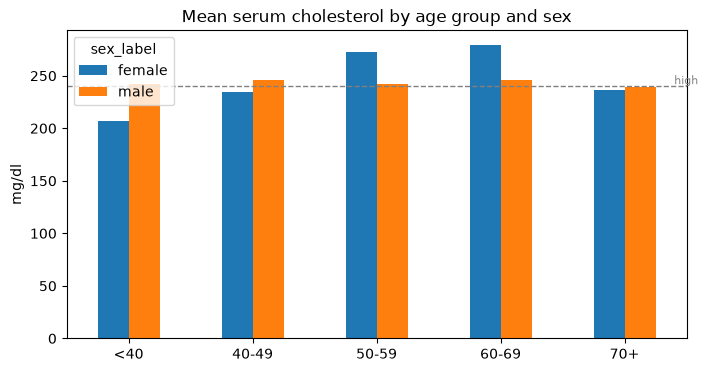

In [18]:
ax = chol_pivot.plot(kind="bar", figsize=(8, 4), rot=0,
                     title="Mean serum cholesterol by age group and sex")
ax.set_ylabel("mg/dl")
ax.axhline(240, linestyle="--", linewidth=1, color="grey")
ax.text(4.4, 242, "high", fontsize=8, color="grey")
ax.set_xlabel("")

Women start ~35 mg/dl **below** men in their thirties and end ~33 mg/dl **above** them
by their sixties — the well-documented post-menopausal lipid shift, visible in a
1988 dataset of 920 people.

### Q2. Disease prevalence by age group and sex

In [19]:
analysis.disease_rate_by(df, "age_group", "sex_label")

n_patients  n_with_disease  disease_rate_pct
age_group sex_label                                              
<40       female             19               3              15.8
          male               61              23              37.7
40-49     female             53               6              11.3
          male              159              79              49.7
50-59     female             72              20              27.8
          male              303             193              63.7
60-69     female             44              20              45.5
          male              178             143              80.3
70+       female              6               1              16.7
          male               25              21              84.0

Prevalence climbs steeply with age in both sexes, and the male rate is roughly double
the female rate at every band — 49.7% vs 11.3% in the forties, 80.3% vs 45.5% in the
sixties.

Read this as a fact about *this cohort*, not the general population: everyone here was
referred for angiography, so they were already suspected of coronary disease.

### Q3. Which vitals actually separate the two groups?

In [20]:
analysis.vitals_by_disease_status(df)

disease_label       disease  no disease
vital    statistic                     
age      mean          55.9        50.5
         median        57.0        51.0
         count        509.0       411.0
trestbps mean         134.3       129.9
         median       130.0       130.0
         count        469.0       391.0
chol     mean         254.0       240.2
         median       248.0       233.0
         count        346.0       372.0
thalach  mean         128.3       148.8
         median       128.0       151.0
         count        474.0       391.0
oldpeak  mean           1.3         0.4
         median         1.0         0.0
         count        468.0       390.0

The cleanest separator is not cholesterol — it is **`thalach`, maximum heart rate
achieved**: 128 bpm in diagnosed patients against 149 in the rest, a 20 bpm gap. A heart
that cannot raise its rate under exercise is the signal. `oldpeak` (ST depression)
separates just as sharply in relative terms, 1.3 vs 0.4.

Cholesterol differs by only 14 mg/dl, well inside a 58 mg/dl standard deviation.

### Q4. Chest pain type

In [21]:
analysis.chest_pain_vs_disease(df)

,n_patients,n_with_disease,disease_rate_pct
cp_label,,,
asymptomatic,496,392,79.0
typical angina,46,20,43.5
non-anginal pain,204,73,35.8
atypical angina,174,24,13.8


The counter-intuitive result: **asymptomatic** patients have by far the highest disease
rate (79%), while textbook *typical angina* sits at 43.5%.

This is a selection effect, not a clinical paradox. Someone with no chest pain who is
nonetheless sent for angiography got there because something else — an abnormal ECG, a
failed stress test — was alarming enough. The referral filter is doing the work.

### Q5. Maximum heart rate by age and diagnosis (pivot table)

In [22]:
hr = analysis.heart_rate_by_age_and_disease(df)
hr

disease_label,disease,no disease
age_group,,
<40,145.5,163.0
40-49,134.9,153.4
50-59,127.0,144.8
60-69,124.3,138.2
70+,119.1,127.9


Text(0.5, 0, '')

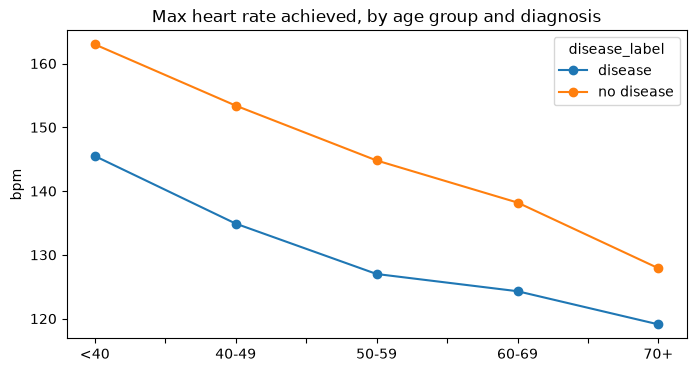

In [23]:
ax = hr.plot(figsize=(8, 4), marker="o",
             title="Max heart rate achieved, by age group and diagnosis")
ax.set_ylabel("bpm")
ax.set_xlabel("")

Two effects at once: maximum heart rate falls with age in *both* groups (normal
physiology), and the diseased group sits 9–19 bpm below the healthy group at *every*
age. The gap is widest in middle age and narrows after 70.

### Q6. Comparing the four institutions

In [24]:
analysis.site_profile(df)

,n_patients,mean_age,pct_male,mean_chol,chol_measured,disease_rate_pct,chol_coverage_pct
institution,,,,,,,
Cleveland Clinic Foundation,303,54.4,68.0,246.7,303,45.9,100.0
Hungarian Institute of Cardiology,294,47.8,72.4,250.8,271,36.1,92.2
University Hospitals Zurich & Basel,123,55.3,91.9,NaN,0,93.5,0.0
V.A. Medical Center,200,59.4,97.0,239.6,144,74.5,72.0


The four databases are not interchangeable samples:

- **Disease rate ranges from 36% to 94%.** Zurich/Basel referred almost exclusively
  patients who turned out to have disease.
- **Sex balance ranges from 68% to 97% male.** The Long Beach VA cohort is a veterans'
  hospital population.
- **Cholesterol coverage ranges from 100% to 0%.** `mean_chol` for Zurich/Basel is
  `NaN`, and that is the correct answer — there is nothing to average.

Pooling these four into one number is defensible only if the site is carried along and
reported, which is why `site` stays in the cleaned export.

### Q7. Severity distribution

In [25]:
analysis.severity_distribution(df)

severity,0,1,2,3,4,All
institution,,,,,,
Cleveland Clinic Foundation,164,55,36,35,13,303
Hungarian Institute of Cardiology,188,106,0,0,0,294
University Hospitals Zurich & Basel,8,48,32,30,5,123
V.A. Medical Center,51,56,41,42,10,200
All,411,265,109,107,28,920


Another schema-level difference: **Hungary only ever recorded severity 0 or 1**, while
the other three used the full 0–4 scale. Any analysis treating `num` as a continuous
severity measure across all sites is comparing incompatible coding practices — which is
exactly why `has_disease` (a binary `num > 0`) is the target used everywhere above.

---
## 7. Merge — attaching institution metadata

`site` is a short key. The human-readable institution details live in a separate lookup
table and are joined on.

In [26]:
sites = pd.DataFrame(cfg.SITE_METADATA)
sites

,site,institution,city,country,principal_investigator
0,cleveland,Cleveland Clinic Foundation,Cleveland,USA,"Robert Detrano, M.D., Ph.D."
1,hungary,Hungarian Institute of Cardiology,Budapest,Hungary,"Andras Janosi, M.D."
2,switzerland,University Hospitals Zurich & Basel,Zurich / Basel,Switzerland,"William Steinbrunn, M.D.; Matthias Pfisterer, ..."
3,long_beach,V.A. Medical Center,"Long Beach, CA",USA,"Robert Detrano, M.D., Ph.D."


In [27]:
# `clean()` already applied this join, so strip the metadata columns back off to
# show the merge on its own.
metadata_cols = [c for c in sites.columns if c != "site"]
patients = df.drop(columns=metadata_cols)

merged = patients.merge(sites, on="site", how="left", validate="many_to_one")
print(f"{len(patients)} rows in -> {len(merged)} rows out")
merged[["site", "institution", "city", "country", "age", "num"]].head()

920 rows in -> 920 rows out


,site,institution,city,country,age,num
0,cleveland,Cleveland Clinic Foundation,Cleveland,USA,63.0,0
1,cleveland,Cleveland Clinic Foundation,Cleveland,USA,67.0,2
2,cleveland,Cleveland Clinic Foundation,Cleveland,USA,67.0,1
3,cleveland,Cleveland Clinic Foundation,Cleveland,USA,37.0,0
4,cleveland,Cleveland Clinic Foundation,Cleveland,USA,41.0,0


Two arguments carry the safety here:

- `how="left"` keeps every patient even if a key fails to match, so a broken join shows
  up as null metadata rather than silently deleted rows.
- `validate="many_to_one"` makes pandas *raise* if the lookup table has duplicate site
  keys — the classic cause of a join that mysteriously multiplies row counts.

---
## 8. Handling the remaining missing values

Two exports are produced, because the right answer depends on the downstream use.

**`heart_clean.csv`** keeps gaps as gaps. Honest, and correct for reporting.

**`heart_imputed.csv`** fills them, for tools that cannot accept `NaN`. Imputation is
done *within site* — a global median would import Cleveland's patient profile into
Switzerland's rows.

In [28]:
imputed = analysis.impute_missing(df)

comparison = pd.DataFrame({
    "missing (clean)": df[cfg.COLUMNS].isna().sum(),
    "missing (imputed)": imputed[cfg.COLUMNS].isna().sum(),
    "mean (clean)": df[analysis.FLOAT_COLUMNS].mean().round(1),
    "mean (imputed)": imputed[analysis.FLOAT_COLUMNS].mean().round(1),
})
comparison

,missing (clean),missing (imputed),mean (clean),mean (imputed)
age,0,0,53.5,53.5
ca,611,0,NaN,NaN
chol,202,0,246.8,244.6
cp,0,0,NaN,NaN
exang,55,0,NaN,NaN
fbs,90,0,NaN,NaN
num,0,0,NaN,NaN
oldpeak,62,0,0.9,0.9
restecg,2,0,NaN,NaN
sex,0,0,NaN,NaN


The means barely move for `trestbps` and `thalach`, where the gaps were modest. Judge
imputed cholesterol with suspicion: 202 of the 718 measured values are absent, and the
entire Swiss cohort had to fall back to the dataset-wide median because its own group
median does not exist.

**Imputation does not create information.** It only makes the shape of the table
convenient — which is why both files are shipped.

---
## 9. Export

In [29]:
clean_path = analysis.export_clean(df, cfg.CLEAN_CSV)
imputed_path = analysis.export_clean(imputed, cfg.IMPUTED_CSV)

for path in (clean_path, imputed_path):
    print(f"{path.relative_to(PROJECT_ROOT)}  ({path.stat().st_size:,} bytes)")

data\clean\heart_clean.csv  (211,775 bytes)
data\clean\heart_imputed.csv  (229,785 bytes)


In [30]:
# Round-trip check: the file on disk reads back with the shape we wrote.
reloaded = pd.read_csv(clean_path)
print(reloaded.shape)
reloaded.head(3)

(920, 31)


,site,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,sex_label,cp_label,restecg_label,slope_label,thal_label,fbs_label,exang_label,age_group,chol_group,bp_group,has_disease,disease_label,institution,city,country,principal_investigator
0,cleveland,63.0,1,1,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,male,typical angina,left ventricular hypertrophy,downsloping,fixed defect,yes,no,60-69,borderline (200-239),stage 2 (140+),False,no disease,Cleveland Clinic Foundation,Cleveland,USA,"Robert Detrano, M.D., Ph.D."
1,cleveland,67.0,1,4,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,male,asymptomatic,left ventricular hypertrophy,flat,normal,no,yes,60-69,high (240+),stage 2 (140+),True,disease,Cleveland Clinic Foundation,Cleveland,USA,"Robert Detrano, M.D., Ph.D."
2,cleveland,67.0,1,4,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,male,asymptomatic,left ventricular hypertrophy,flat,reversible defect,no,yes,60-69,borderline (200-239),elevated (120-129),True,disease,Cleveland Clinic Foundation,Cleveland,USA,"Robert Detrano, M.D., Ph.D."


---
## Key findings

1. **Missingness in this dataset is structural, not random.** `ca` and `thal` are absent
   for 90–99% of patients outside Cleveland. Pooled statistics on those columns describe
   one hospital.

2. **172 cholesterol values are sentinel zeros** — all 123 Swiss readings plus 49 at
   Long Beach. Treating them as real measurements moves the pooled mean from 247 to
   199 mg/dl, relabelling the cohort from "high" to "desirable".

3. **Maximum heart rate separates the groups better than cholesterol.** 128 bpm vs
   149 bpm for `thalach`, against a 14 mg/dl gap for cholesterol inside a 58 mg/dl
   standard deviation.

4. **Cholesterol crosses over by sex at around age 50** — women move from 35 mg/dl below
   men to 33 mg/dl above them.

5. **Asymptomatic patients have the highest disease rate (79%).** A referral-selection
   effect, and a reminder that a cohort's entry criteria shape every rate computed from it.

6. **Hungary only coded severity 0–1** where the others used 0–4, so the binary
   `has_disease` is the only target comparable across all four sites.

---

*The same tables are generated non-interactively by `python -m src.analysis`, which
writes [`reports/summary_stats.md`](../reports/summary_stats.md).*